# Downloading Digital Surface Model (DSM) and Digital Terrain Model (DTM) files
### Demonstration Notebooks
#### Author: Rafael Barbedo | Date: 2025-03-12

Digital Elevation data derived from LiDAR—specifically Digital Terrain Models (DTMs) and Digital Surface Models (DSMs)—are highly valuable for a wide range of geospatial analyses, including hydrology, terrain characterisation, and land assessment.

This notebook demonstrates how to **download, extract and visualise** DSM and DTM data for a user-defined region of interest (ROI).

- **DTM** (Digital Terrain Model): Represents the bare-earth surface, with vegetation and built structures removed.
- **DSM** (Digital Surface Model): Includes surface features such as vegetation, buildings, and other structures.

Subsequent notebooks will build on these datasets to perform more advanced analyses (e.g. hydrological modelling and canopy assessment). In this notebook, we focus on data acquisition and preprocessing.

A vector layer representing the study catchment is used to define the region of interest (ROI). This is used to generate a bounding box, which is then applied to clip the DTM and DSM datasets.

All processing steps are reproducible using open-source tools.

**Required inputs:**
- Vector layer or bounding box for region of interest

**Workflow overview:**
- Define inputs
- Handle CRS
- ROI extraction
- Preprocessing
- Outputs

**Outputs:**
- Interactive 3D Terrain Model
- TIFF files: DTM and DSM extracted for ROI

**Warnings**
- This workbook reads data directly into memory. When working with large datasets, ensure sufficient RAM is available 
to avoid performance issues or crashes. Consider using smaller regions of interest if working with limited system 
memory.

First, will start with importing the necessary libraries...

In [6]:
# Import the necessary pacakages
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
import rasterio
import numpy as np
import plotly.graph_objects as go
from pathlib import Path

from rasterio.enums import Resampling
from osgeo import gdal
from osgeo import ogr
import shapely

In [15]:
# Define input files as global variables:
INPUT_DTM_RASTER = "/vsicurl/https://fdri-o.s3-ext.jc.rl.ac.uk/lidar/joined/merged_engwal_dtm.tif"
INPUT_DSM_RASTER = "/vsicurl/https://fdri-o.s3-ext.jc.rl.ac.uk/lidar/joined/merged_engwal_dsm.tif"

# Update your working directory
PROJECT_ROOT = Path().resolve()
print(PROJECT_ROOT)

# Set your data and output directories
DATA_DIR = PROJECT_ROOT / "GIthub/dtm-analysis/data"
OUTPUT_DIR = DATA_DIR / "output"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Choose your region of interest and output paths
INPUT_SHP = DATA_DIR / "nrfa_39088/NRFA_catchments.shp"
OUTPUT_DTM_RASTER = OUTPUT_DIR / "dtm_39088_extract.tif"
OUTPUT_DSM_RASTER = OUTPUT_DIR / "dsm_39088_extract.tif"

/home/users/ambbar


In [18]:
def correct_crs(input_dtm: str, input_roi: str, roi_crs: str | None = None,)-> gpd.GeoDataFrame:

    """
    Ensure that the CRS of the input ROI vector layer matches the DTM/DSM rasters.

    If the ROI vector layer has no CRS, it is assigned using `roi_crs`.
    If the CRS differs, the ROI vector layer is reprojected to match the raster CRS.

    Also optionally prints resolution and spatial extent for validation.

    Parameters
    ----------
    input_dtm : Path or str
        Path to the DTM raster
    input_roi : Path or str
        Path to the ROI vector layer
    roi_crs : str, optional
        CRS to assign if ROI vector layer is not found but known (e.g. "EPSG:27700"). Note: this won't reproject, only
        assign a projection. 

    Returns
    -------
    gpd.GeoDataFrame
        ROI vector layer reprojected to match raster CRS
    """

    # Load the data with geopandas
    roi_gdf = gpd.read_file(input_roi)

    # store the crs, resolution and bounds of the DTM
    with rasterio.open(input_dtm) as dtm:
        dtm_crs = dtm.crs
        dtm_res = dtm.res
        print(f'DTM resolution is {dtm_res}')

    # Check for geographic coordinate system
    if roi_gdf.crs is not None and roi_gdf.crs.is_geographic:
        raise ValueError(f"{roi_gdf} is in a geographic CRS, please reproject to a projected CRS (e.g. BNG)")
    
    if dtm_crs is not None and dtm_crs.is_geographic:
        raise ValueError(f"{input_dtm} is in a geographic CRS, please reproject to a projected CRS (e.g. BNG)")

    # Assign a CRS is undefined 
    if roi_gdf.crs is None:
        if roi_crs.crs is None:
            raise ValueError("ROI CRS is undefined. Please provide `roi_crs`.")

        print(f'Assigning CRS {roi_crs} to ROI layer')
        roi_gdf = roi_gdf.set_crs(roi_crs)

    # Reproject if needed
    if roi_gdf.crs != dtm_crs:
        print(f"Reprojecting shapefile from {roi_gdf.crs} to {dtm_crs}")
        roi_gdf = roi_gdf.to_crs(dtm_crs)
    else:
        print(f"DTM CRS of {dtm.crs} already matches the ROI CRS of {roi_gdf.crs}")
        

    return roi_gdf

In [19]:
roi_gdf = correct_crs(INPUT_DTM_RASTER, INPUT_SHP)

# save the returned geodataframe to file
roi_gdf_path = OUTPUT_DIR / "roi.shp"
roi_gdf.to_file(roi_gdf_path, driver ='GPKG')


DTM resolution is (1.0, 1.0)
DTM CRS of EPSG:27700 already matches the ROI CRS of EPSG:27700


### Now, using gdal_translate to get hold of the DTM data at the area of study, resampled to 5 m. We also converted the data to metres, and float.

Using the DTM for England and Wales, select a shapefile of your study area to clip the raster to and define an output for this new clipped raster. The pixel size is the size of the individual grid cells that make up the raster image, a lower value will give a higher resolution. In this case, 5 represents grid cells of 5m and an optional buffer of 1000m. Processing will be much faster when selecting a smaller bounding box.

In [20]:
# The function get_raster_at_roi is used to extract dtm and dsm data for a region of interest.
def get_raster_at_roi(input_raster, input_vector, clipped_output_raster, pixel_size=5, buffer=1000) -> str:
    """
    Extracts a raster for a region of interest (ROI) defined by a vector layer.
    The function retrieves a raster from an online source (e.g., AWS S3, URL), 
    clips it to the shapefile extent with an optional buffer, and saves it locally.

    Parameters:
    - input_raster (str): URL or S3 path to the input raster.
    - input_vector (str): Path to the vector file defining the region of interest (ROI).
    - output_raster (str): Path to save the clipped raster.
    - pixel_size (int, optional): Output pixel size in meters (default = 5m).
    - buffer (int, optional): Buffer distance (meters) to extend the clipping extent (default = 1000m).

    Returns:
    - Prints GDAL command output and saves the clipped raster.
    """

    # load input raster
    input_ds = gdal.Open(input_raster)

    if input_ds is None:
        raise ValueError(f'Error opening dem:{input_ds}')

    # load region of interest input vector
    input_vector = ogr.Open(input_vector)

    if input_vector is None:
        raise ValueError(f'Error opening roi layer:{input_vector}')

    # get the first layer and the extent of shapefile 
    sf_layer = input_vector.GetLayer(0)

    min_x, max_x, min_y, max_y = sf_layer.GetExtent()
    print(f" current layer extent is: {min_x, min_y, max_x, max_y}")

    # add buffer, default is 1000 (meters as the CRS is BNG) and resample output
    bbox = shapely.geometry.box(min_x, min_y, max_x, max_y)
    buffered_bbox = bbox.buffer(buffer)

    # rearrange the order for gdal to use
    min_x, min_y, max_x, max_y = buffered_bbox.bounds
    projwin = (min_x, max_y, max_x, min_y)

    # check over the new coordinates
    print(f" creating new buffered extent of: {projwin}")

    # clip raster to bounding box of extent and write out to file.
    gdal.Translate(clipped_output_raster,
                   input_ds,
                   projWin=projwin, # defines region to extract
                   xRes=pixel_size, # defines new resolution in the CRS units
                   yRes=pixel_size,
                   resampleAlg=gdal.GRA_Bilinear,  # resampling method generally used for DEM data
                   format="GTiff" # output format 
)

    print(f'Clipped DEM file creating and written to {clipped_output_raster}')

    return clipped_output_raster

In [21]:
# Run the function on the DTM 
clipped_dtm = get_raster_at_roi(INPUT_DTM_RASTER, roi_gdf_path, OUTPUT_DTM_RASTER, pixel_size=5, buffer=1000)

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/osgeo/gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


 current layer extent is: (488725.0, 194775.0, 506975.0, 210175.0)
 creating new buffered extent of: (487725.0, 211175.0, 507975.0, 193775.0)
Clipped DEM file creating and written to /home/users/ambbar/GIthub/dtm-analysis/data/output/dtm_39088_extract.tif


In [22]:
# Run the function on the DSM 
clipped_dsm = get_raster_at_roi(INPUT_DSM_RASTER, roi_gdf_path, OUTPUT_DSM_RASTER, pixel_size=5, buffer=1000)

 current layer extent is: (488725.0, 194775.0, 506975.0, 210175.0)
 creating new buffered extent of: (487725.0, 211175.0, 507975.0, 193775.0)
Clipped DEM file creating and written to /home/users/ambbar/GIthub/dtm-analysis/data/output/dsm_39088_extract.tif


## Now let's visualize our dataset
To ensure consistency in visualizing raster outputs, we define a function that:
- **Loads and normalizes raster values.**
- **Displays georeferenced coordinates.**
- **Adds a histogram inset for value distribution.**

In [23]:

def plot_raster_with_histogram(raster_path: str, title: str):
    """ 
    Plot a raster with real-world extent, colour scaling and histogram.

    Parameters:
    raster_path : str
        Path to raster file
    title : str
        Title for the plot
    label : str
        Label for the colorbar
    color_scheme : str
        colour map for the plot
    """

    # Load raster with rasterio to get georeferencing
    with rasterio.open(raster_path) as src:
        raster = src.read(1)  # Read the first band
        bounds = src.bounds  # Get raster bounding box
        nodata = src.nodata  # NoData value

    # Mask out NoData values
    if nodata is not None:
        valid_data = raster[raster != nodata]
    else:
        valid_data = raster[np.isnan(raster)]

    if valid_data.size == 0:
        raise ValueError("No valid raster values found.")

    # Compute Color Normalization
    datamin = np.percentile(valid_data, 2)
    datamax = np.percentile(valid_data, 98)
    norm = colors.Normalize(vmin=datamin, vmax=datamax)
    cmap = "terrain"

    # Compute Real-World Extent
    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

    # Plot
    _, ax = plt.subplots(figsize=(10, 6))

    # Display the raster with real-world extent
    img = ax.imshow(raster, cmap=cmap, norm=norm, extent=extent, origin="upper")

    # Display the raster with real-world extent #img =
    ax.imshow(raster, cmap=cmap, norm=norm, extent=extent, origin="upper")
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.set_title(title)
    
    # Create a colorbar
    cbar = plt.colorbar(img, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Elevation (m)")
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cax = ax.inset_axes([1.3, 0.35, 0.06, 0.5])  # Position the colorbar inset
    cbar = plt.colorbar(sm, cax=cax)
    cbar.ax.tick_params(labelsize=8)
    cax.yaxis.set_ticks_position('right')
    cax.yaxis.set_label_position('right')

    # Histogram inset
    hax = ax.inset_axes([1.2, 0.05, 0.25, 0.25])
    colormap = plt.colormaps.get_cmap(cmap)

    # Filter raster values for histogram
    data = valid_data[(valid_data > datamin) & (valid_data < datamax)]

    # Plot % histogram
    n = len(data)
    _, bins, patches = hax.hist(data, bins=20, edgecolor='none', weights=np.ones(n)/n*100)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    # Normalize bin centers to [0, 1]
    col = (bin_centers - min(bin_centers)) / (max(bin_centers) - min(bin_centers))

    for c, p in zip(col, patches):
            plt.setp(p, 'facecolor', colormap(c))

    hax.set_xlabel('Elevation (m)')
    hax.set_ylabel('Occupation (%)')
    hax.yaxis.set_ticks_position('right')
    hax.yaxis.set_label_position('right')

    plt.tight_layout()
    plt.show()

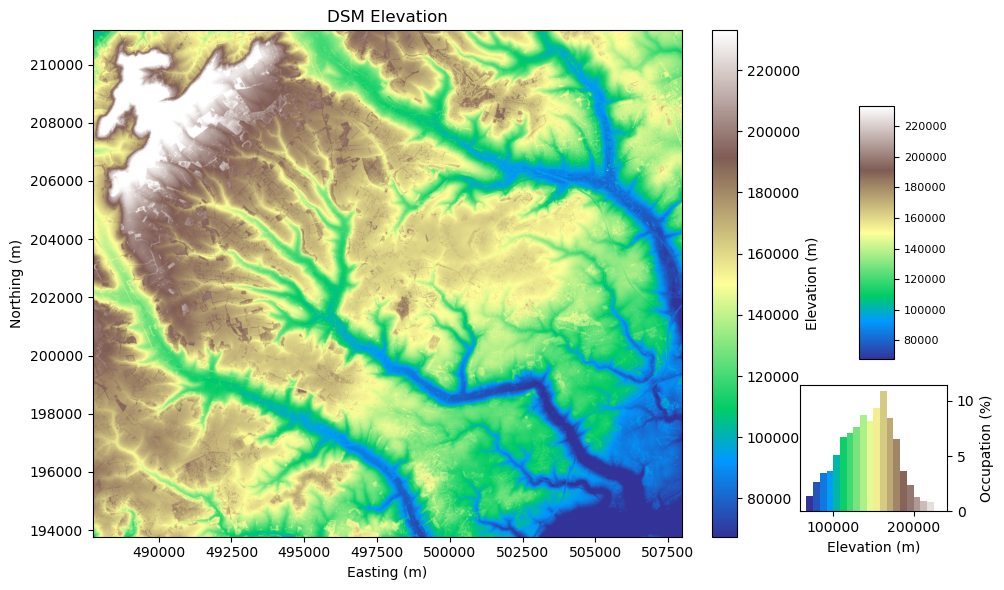

In [24]:
# Call the function with the clipped DTM or DSM raster 
plot_raster_with_histogram(OUTPUT_DSM_RASTER, "DSM Elevation")

## For interactive visualization

## 3D visualization

In [ ]:
# Load the Raster
raster_path = OUTPUT_DTM_RASTER

# Read the raster and resample for performance
with rasterio.open(raster_path) as src:

    # reducing the resolution by a factor of 10 to help with performance
    scale = 10

    new_height = src.height // scale
    new_width = src.width // scale

    # Read the first band (elevation) with resampling
    data = src.read(
        1,
        out_shape=(new_height, new_width),
        resampling=Resampling.bilinear
    )

    # Transform gets the affine matrix, used to get the spatial positioning and plot from an array to world coordinates
    """
    a → pixel width (x-scale)
    b → row rotation (usually 0)
    c → x-origin (top-left corner)
    d → column rotation (usually 0)
    e → pixel height (y-scale, often negative)
    f → y-origin (top-left corner)
    """

    # resize with transform.scale 
    transform = src.transform * src.transform.scale(
        src.width / new_width,
        src.height / new_height
    )

    rows, cols = data.shape

    # convert pixel indices into real world coordinates, referring the the affine matrix (a-f)
    x_coords = np.arange(cols) * transform.a + transform.c
    y_coords = np.arange(rows) * transform.e + transform.f

    # create a grid out of the x and y coordinates
    X, Y = np.meshgrid(x_coords, y_coords)

    # Mask nodata values
    nodata = src.nodata
    data = np.where(data == nodata, np.nan, data)

    # Design the colourscale, alternatively you can use a predefined one e.g. 'ylgrn', adding '_r' will reverse it.
    cmap= [[0, 'rgb(91,155,150)'], [0.25,'rgb(113,192,161)'],[0.5, 'rgb(204,170,102)'], 
           [0.75, 'rgb(249,255,204)'], [1, 'rgb(255,255,255)']]

    # Plotly interactive surface
    fig = go.Figure(
        data=[
            go.Surface(
                z=data,
                x=X,
                y=Y,
                colorscale=cmap
            )
        ]
    )

    # Add contours
    fig.update_traces(contours_z=dict(show=True, usecolormap=True,
                                    highlightcolor="limegreen", project_z=True))
    
    # Layout + styling
    fig.update_layout(
        title="Interactive 3D Terrain Model",
        scene=dict(
            xaxis_title="Easting",
            yaxis_title="Northing",
            zaxis_title="Elevation (m)",
            aspectratio=dict(x=1, y=1, z=0.3)
        ),
        margin=dict(l=0, r=0, t=40, b=0)
    )
    # Show plot
    fig.show()